## DATA LOAD

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Read data
data = pd.read_csv(r"C:\Users\jinog\OneDrive\Documents\LUT STUDIES\JOB\Master Thesis\Antti kosannan, LUT\initial task\data.txt", delimiter=',')
solar_power_data = data['data']
# System parameters
Pe_nom = 1000  # nominal power of electrolyzer in kW
HHV_hydrogen = 39.41  # kWh/kg
min_operating_power = 0.2 * Pe_nom  # 20% of nominal power

# Battery parameters
battery_efficiency = 0.92
battery_min = 0.10 # min SOC
battery_max = 1    # max SOC


# Cost parameters
capex_pv = 580  # €/kWp
capex_battery = 405  # €/kWh
capex_electrolyzer = 564  # €/kW
opex_pv = 13.2  # €/kWp per year
opex_battery = 9  # €/kWh per year
opex_electrolyzer = 19.7  # €/kW per year

# Economic parameters
discount_rate = 0.05
lifetime = 20

## Functions

In [2]:
def electrolyzer_efficiency(Pe):
    """Calculate electrolyzer efficiency based on input power"""
    return 5.24 * (Pe / Pe_nom)**2 - 14.99 * (Pe / Pe_nom) + 85.67

def simulate_system(pv_peak_power, battery_capacity):
    """Simulate the hydrogen production system for one year"""
    battery_state = battery_max * battery_capacity  # Start at maximum state of charge
    hydrogen_production = []
    battery_states = []
    electrolyzer_power = []
    hourly_H2 = []
    
    for solar_power_hour in solar_power_data * pv_peak_power:
        available_power = solar_power_hour
                
        # Battery state constraints
        usable_battery = battery_state - (battery_min * battery_capacity)
        max_discharge = min(usable_battery * battery_efficiency, 
                            battery_capacity * (battery_max - battery_min))
        
        # Electrolyser constrains modelling
        if available_power < min_operating_power: # Case 1a
            # Try to use battery to reach minimum operating power
            power_needed = min_operating_power - available_power
            if power_needed <= max_discharge:
                available_power = min_operating_power
                battery_state -= power_needed / battery_efficiency
                Pe = min_operating_power
                efficiency = electrolyzer_efficiency(Pe)
                H2 = (Pe * efficiency/100) / HHV_hydrogen
                hydrogen_production.append(H2)
                battery_states.append(battery_state)
                
            elif ((power_needed >= max_discharge) and (available_power>0)): # Case 1b
                # Can't reach minimum operating power
                # Charge battery with lost power also avoid heating in PV pannels
                max_charge = (battery_max * battery_capacity - battery_state) / battery_efficiency
                battery_charge = min(available_power, max_charge)
                battery_state += battery_charge * battery_efficiency
                
                hydrogen_production.append(0)
                battery_states.append(battery_state)
                electrolyzer_power.append(0)
            
            else:
                # Available power is 0 # Case 1c
                hydrogen_production.append(0)
                battery_states.append(battery_state)
                electrolyzer_power.append(0)
                continue
                
        Pe = available_power   # Case 2a
        if (available_power > min_operating_power) and (available_power<= Pe_nom):
            efficiency = electrolyzer_efficiency(Pe)
            H2 = (Pe * efficiency/100) / HHV_hydrogen
            hydrogen_production.append(H2)
            battery_states.append(battery_state)
            electrolyzer_power.append(Pe)
        elif (available_power > min_operating_power) and (available_power> Pe_nom):  # Case 2b
            efficiency = electrolyzer_efficiency(Pe_nom)
            H2 = (Pe_nom * efficiency/100) / HHV_hydrogen
            # Charge battery with excess power
            excess_power = available_power - Pe_nom
            max_charge = (battery_max * battery_capacity - battery_state) / battery_efficiency
            battery_charge = min(excess_power, max_charge)
            battery_state += battery_charge * battery_efficiency
            hydrogen_production.append(H2)
            battery_states.append(battery_state)
            electrolyzer_power.append(Pe)            
        else: # Case 2c
            H2 =0
            
#         hydrogen_production.append(H2)
#         battery_states.append(battery_state)
#         electrolyzer_power.append(Pe)
    return {
        'hydrogen_production': sum(hydrogen_production),
        'battery_states': battery_states,
        'electrolyzer_power': electrolyzer_power,
        "hourly_H2": (hydrogen_production)
    }


def calculate_lcoh2(pv_peak_power, battery_capacity, annual_h2_production):
    """Calculate Levelized Cost of Hydrogen with discounted CAPEX and OPEX."""
    # Discounted CAPEX
    capex_pv_discounted = pv_peak_power * capex_pv
    capex_battery_discounted = battery_capacity * capex_battery 
    capex_electrolyzer_discounted = Pe_nom * capex_electrolyzer
    
    # Total discounted CAPEX
    total_capex_discounted = (
        capex_pv_discounted +
        capex_battery_discounted +
        capex_electrolyzer_discounted
    )
      
    # Discounted OPEX (across all years)
    annual_opex = (
        pv_peak_power * opex_pv +
        battery_capacity * opex_battery +
        Pe_nom * opex_electrolyzer
    )
    discounted_opex = sum(
        annual_opex / (1 + discount_rate)**i for i in range(1, lifetime + 1)
    )
    
    # Total discounted costs
    total_discounted_costs = total_capex_discounted + discounted_opex
    
    # Discounted hydrogen production
    discounted_h2_production = sum(
        annual_h2_production / (1 + discount_rate)**i for i in range(1, lifetime + 1)
    )
    
    return total_discounted_costs / discounted_h2_production if discounted_h2_production > 0 else float('inf')


def objective_function(x):
    """Optimization objective function."""
    pv_peak_power, battery_capacity = x
       
    # Simulate system
    results = simulate_system(pv_peak_power, battery_capacity)
    
    # Calculate LCOH2
    lcoh2 = calculate_lcoh2(pv_peak_power, battery_capacity, 
                           results['hydrogen_production'])
    
    return lcoh2

## Optimization

In [3]:
# Optimization setup
initial_guess = [500, 100]  # Initial guess for [PV power(kW), Battery capacity (kW)]
bounds = [(500, 50000), (100, 200000)]  # Reasonable bounds for parameters

# Perform optimization
result = minimize(
    objective_function,
    initial_guess,
    method='Powell',   #method='Powell' #SLSQP #trust-constr
    bounds=bounds,
    options={'maxiter': 500, 'ftol': 1e-6}
)

# Extract and print results
optimal_pv, optimal_battery = result.x
optimal_lcoh2 = result.fun
print(f"\nOptimization Results:")
print(f"Optimal PV Peak Power: {optimal_pv:.2f} kWp")
print(f"Optimal Battery Capacity: {optimal_battery:.2f} kWh")
print(f"Minimum LCOH2: {optimal_lcoh2:.2f} €/kg")

# Simulate final system for detailed results
final_results = simulate_system(optimal_pv, optimal_battery)
annual_h2 = final_results['hydrogen_production']
print(f"Annual Hydrogen Production: {annual_h2:.2f} kg")


Optimization Results:
Optimal PV Peak Power: 2150.31 kWp
Optimal Battery Capacity: 180.72 kWh
Minimum LCOH2: 6.56 €/kg
Annual Hydrogen Production: 30640.77 kg


## Graphs

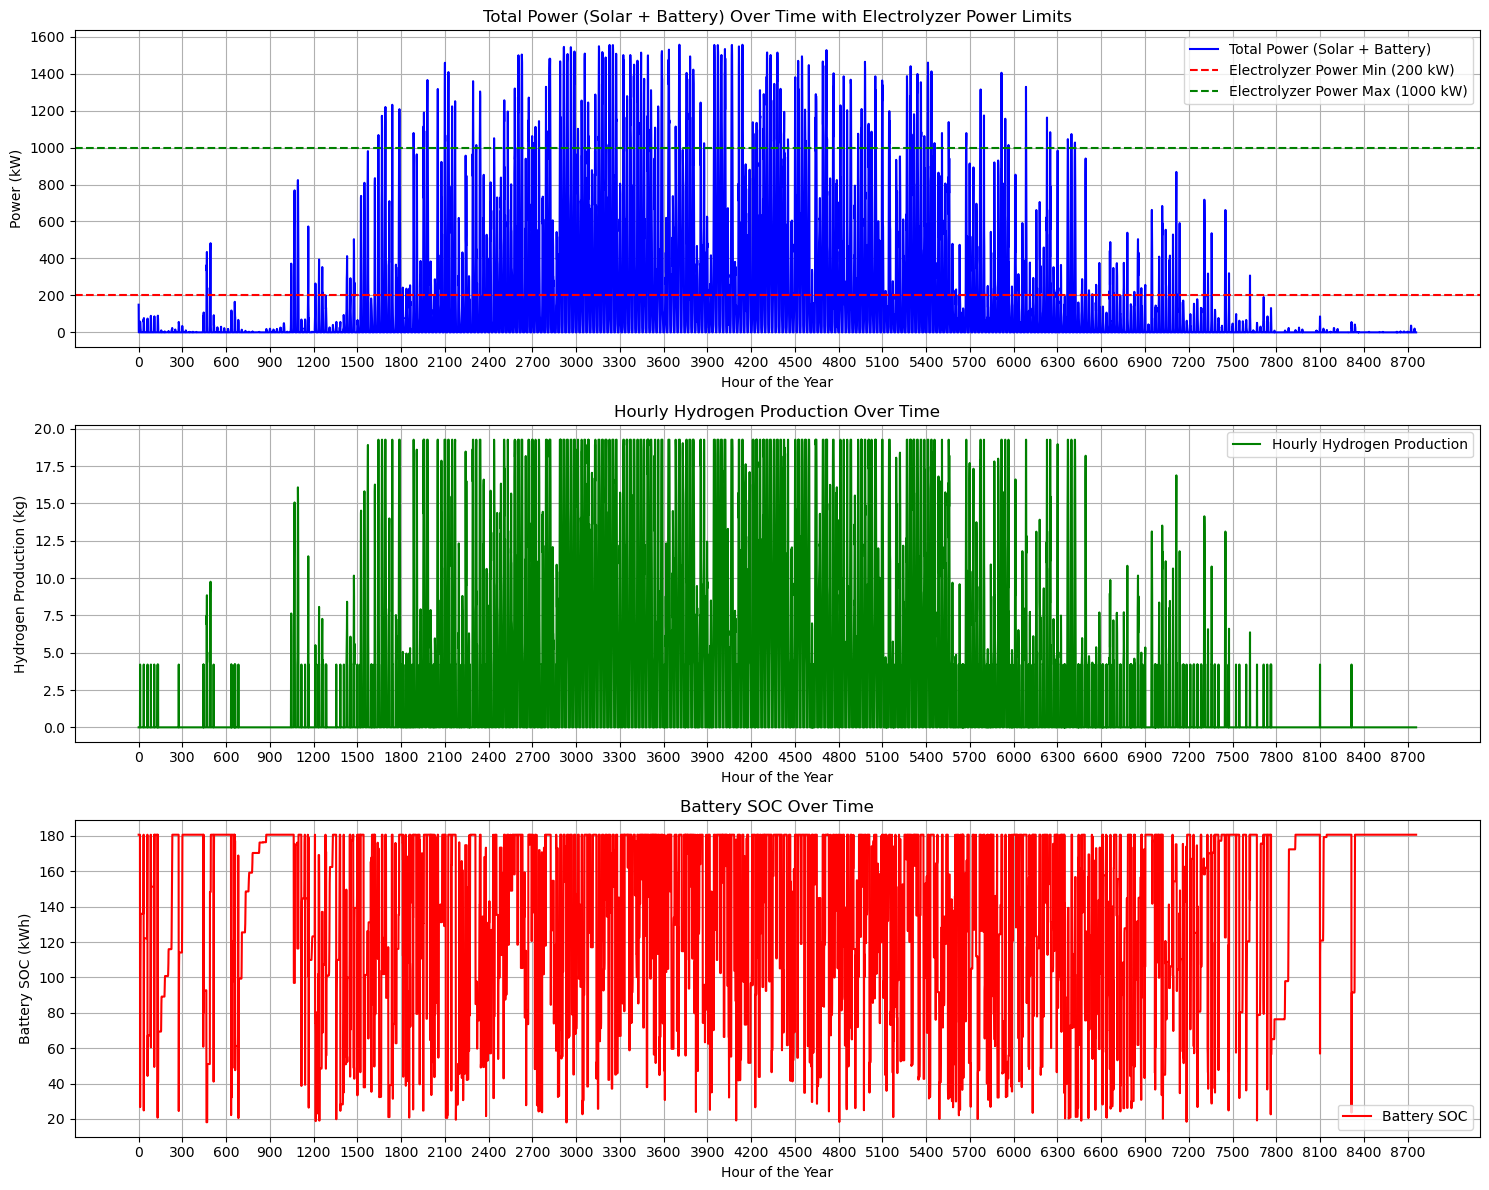

In [4]:
def calculate_total_power(pv_peak_power, battery_capacity):
    # Battery state initialization
    battery_state = battery_capacity * battery_max  # Start at maximum state of charge

    # List to store results
    total_power = []

    # Loop through solar power data
    for solar_power_hour in solar_power_data:
        available_power = solar_power_hour * pv_peak_power  # Adjust solar power based on PV peak
        
        # Battery state constraints
        usable_battery = battery_state - (battery_min * battery_capacity)  # Usable energy from the battery
        max_discharge = min(usable_battery * battery_efficiency, 
                            battery_capacity * (battery_max - battery_min))  # Maximum discharge
        
        # Calculate total power (solar power + battery discharge)
        total_power_hour = available_power + max_discharge
        
        # Update battery state after discharge
        battery_state -= max_discharge / battery_efficiency  # Reduce battery state according to efficiency

        # Make sure battery doesn't go below minimum state of charge
        if battery_state < battery_min * battery_capacity:
            battery_state = battery_min * battery_capacity
        
        # Append the result to the list
        total_power.append(total_power_hour)

    return total_power


total_power = calculate_total_power( pv_peak_power=optimal_pv, battery_capacity=optimal_battery)



# Simulate the system with the optimal PV and battery values
results = simulate_system(optimal_pv, optimal_battery)

# Extract data for the plots
hourly_h2_production = results['hourly_H2']
battery_states = results['battery_states']

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(15, 12))

# Plotting the total power
axs[0].plot(total_power, label="Total Power (Solar + Battery)", color='b')
axs[0].axhline(200, color='r', linestyle='--', label="Electrolyzer Power Min (200 kW)")
axs[0].axhline(1000, color='g', linestyle='--', label="Electrolyzer Power Max (1000 kW)")
axs[0].set_xlabel('Hour of the Year')
axs[0].set_ylabel('Power (kW)')
axs[0].set_title('Total Power (Solar + Battery) Over Time with Electrolyzer Power Limits')
axs[0].legend()
axs[0].grid(True)
axs[0].set_xticks(range(0, len(total_power), 300))  # Set x-axis ticks at intervals of 500


# Plotting hourly hydrogen production
axs[1].plot(hourly_h2_production, label="Hourly Hydrogen Production", color='g')
axs[1].set_xlabel('Hour of the Year')
axs[1].set_ylabel('Hydrogen Production (kg)')
axs[1].set_title('Hourly Hydrogen Production Over Time')
axs[1].legend()
axs[1].grid(True)
axs[1].set_xticks(range(0, len(hourly_h2_production), 300))  # Set x-axis ticks at intervals of 500


# Plotting battery state of charge (SOC) over time
axs[2].plot(battery_states, label="Battery SOC", color='r')
axs[2].set_xlabel('Hour of the Year')
axs[2].set_ylabel('Battery SOC (kWh)')
axs[2].set_title('Battery SOC Over Time')
axs[2].legend()
axs[2].grid(True)
axs[2].set_xticks(range(0, len(battery_states), 300))  # Set x-axis ticks at intervals of 500


plt.tight_layout()

# Show the plot
plt.show()


# Excel formation if needed for total power

In [5]:
# Example total_power list (you should already have this in your code)
total_power = total_power# Replace with your actual total_power list


# Convert total_power to a pandas DataFrame
df = pd.DataFrame(total_power, columns=['Total Power'])

# Save the DataFrame to an Excel file
df.to_excel('total_power_data3.xlsx', index=False)  # 'index=False' prevents writing row numbers

print("Data saved to total_power_data.xlsx")

Data saved to total_power_data.xlsx


In [6]:
def Electrolyser(total_power):
    total_power_array = np.array(total_power)
    print(f"Minimum Power: {min(total_power_array)}")
    print(f"Maximum Power: {max(total_power_array)}")
    print(f"Number of Hours Below 200: {np.sum(total_power_array < 200)}")
    print(f"Number of Hours Equal to 200: {np.sum(total_power_array == 200)}")
    plt.hist(total_power_array, bins=50, color='b', edgecolor='k')



## HEAT MAP

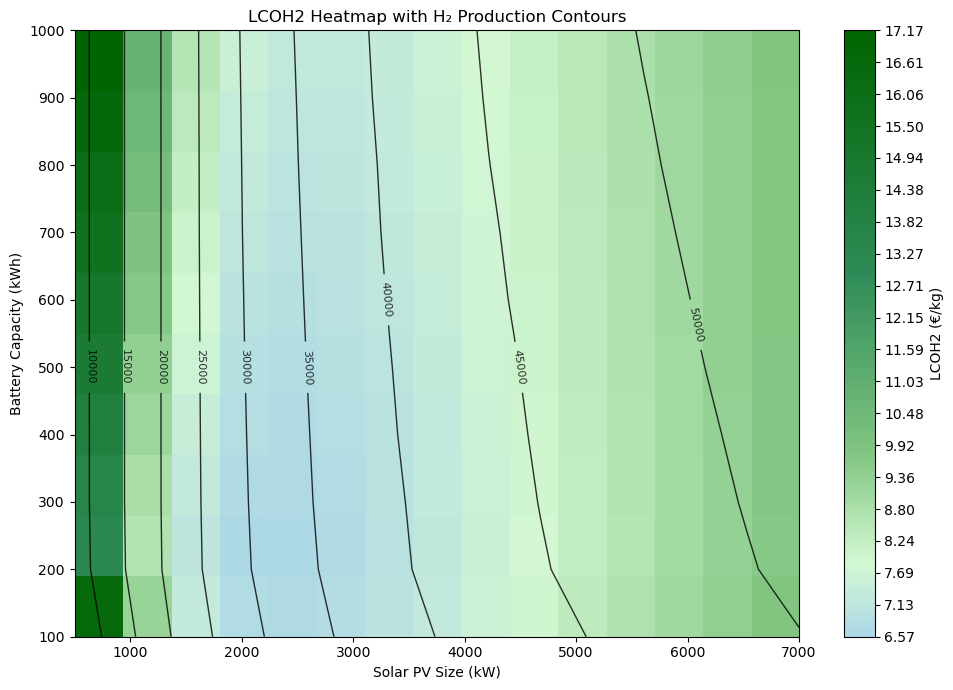

In [7]:
# Define ranges for PV peak power and battery capacity
pv_range = np.linspace(500, 7000, 15)  # PV size in kW
battery_range = np.linspace(100, 1000, 10)  # Battery capacity in kWh

# Initialize result arrays
lcoh2_results = np.zeros((len(battery_range), len(pv_range)))
hydrogen_production_results = np.zeros((len(battery_range), len(pv_range)))

# Perform sensitivity analysis
for i, battery_capacity in enumerate(battery_range):
    for j, pv_peak_power in enumerate(pv_range):
        # Simulate the system
        simulation_results = simulate_system(pv_peak_power, battery_capacity)
        annual_h2_production = simulation_results['hydrogen_production']
        
        # Calculate LCOH2
        lcoh2 = calculate_lcoh2(pv_peak_power, battery_capacity, annual_h2_production)
        
        # Store results
        hydrogen_production_results[i, j] = annual_h2_production
        lcoh2_results[i, j] = lcoh2

# Create a custom colormap with light blue for values between 0-12 LCOE and green for higher values
colors = [(0.0, "#add8e6"),   # Light Blue for 0-12 LCOE
          (0.12, "#d3f8d3"),  # Light Green for LCOE just above 12
          (0.3, "#82c682"),   # Medium Light Green
          (0.6, "#2e8b57"),   # Green
          (1.0, "#006400")]   # Dark Green for high values

custom_cmap = LinearSegmentedColormap.from_list("green_and_blue_shades_custom", colors)

# Plot the results
fig, ax = plt.subplots(figsize=(10, 7))

# Heatmap for LCOH2 with custom colormap
heatmap = ax.imshow(
    lcoh2_results, 
    extent=[pv_range[0], pv_range[-1], battery_range[0], battery_range[-1]], 
    origin='lower', 
    aspect='auto', 
    cmap=custom_cmap  # Apply custom colormap with green and blue shades
)

min_lcoh2_value = np.min(lcoh2_results)
max_lcoh2_value = np.max(lcoh2_results)

ax.set_title('LCOH2 Heatmap with H₂ Production Contours')
ax.set_xlabel('Solar PV Size (kW)')
ax.set_ylabel('Battery Capacity (kWh)')

# Add colorbar with adjusted ticks
cbar = plt.colorbar(heatmap, ax=ax, label='LCOH2 (€/kg)')
cbar.set_ticks(np.linspace(min_lcoh2_value, max_lcoh2_value, 20))  # Set the colorbar ticks from 0 to 100 in intervals of 5

# Contours for Hydrogen Production with black contour lines
contour = ax.contour(
    pv_range, 
    battery_range, 
    hydrogen_production_results, 
    levels=10, 
    colors='black', # Set contour lines to black
    linewidths=1,
    alpha=0.8
)
ax.clabel(contour, inline=True, fontsize=8, fmt="%.0f")  # Add labels to contours

plt.tight_layout()
plt.show()


## Decsison maker

In [8]:
a= 4000
b= 800

x= simulate_system(a, b)
print(f"The H2 produced is: {(x['hydrogen_production'])/1000:3f}_tonnes")

y= calculate_lcoh2(a, b, x['hydrogen_production'])
print(f"the LCOH2 is: {y}")






The H2 produced is: 44.029687_tonnes
the LCOH2 is: 7.656611819220859
